# Chapter 59: Threshold Optimization

**How far does the development F1 of a tuned threshold overstate its F1 on fresh labels, and how does that depend on the size of the development set?**

A threshold is a fitted parameter chosen to maximize the metric on rows whose labels it can exploit. The best search score is a development result, optimistic by an amount that depends on how many positives the search saw.

*Constructed data with a stable relationship. The gain from averaging fold thresholds is small here (about 0.01 at 100 rows); sizes depend on the model's strength and the metric.*

## The experiment

A constructed binary task with 5% positives and five noisy features. A logistic regression is fitted once on 5,000 rows. For each development-set size, 300 independent development sets are drawn; on each, the threshold that maximizes F1 is found by scanning every cut of the sorted scores, then frozen and scored on 50,000 fresh rows with the same prevalence. Also reported: the default 0.5, the best possible threshold (tuned on the 50,000 audit rows, a ceiling no real search sees), the average of five thresholds each tuned on the development set with one fifth held back, and the frozen threshold on audits with 1% and 20% positives.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression

from kaggle_companion.activities._common import clean

SEED = 59
PREVALENCE = 0.05            # share of positive rows when the model and the threshold are fitted
DRAWS = 300                  # independent development sets per size; results are means over draws
AUDIT_ROWS = 50000           # fresh rows used only for scoring
SHIFTS = [0.01, 0.05, 0.20]  # audit prevalences used to test the frozen threshold


def generate(n, prevalence, rng):
    """Five noisy features; each shifts a little for positive rows."""
    y = (rng.random(n) < prevalence).astype(int)
    X = rng.normal(size=(n, 5)) + y[:, None] * np.array([1.0, 0.8, 0.6, 0.4, 0.2])
    return X, y


class Scored:
    """Rows sorted by score, so F1 at any threshold costs one search instead of one pass."""
    def __init__(self, p, y):
        order = np.argsort(p)
        self.p, self.y = p[order], y[order]
        self.positives_from = np.r_[np.cumsum(self.y[::-1])[::-1], 0]   # positives among rows at or above each position
        self.total = int(y.sum())

    def f1(self, threshold):
        """F1 when every row with score >= threshold is called positive."""
        i = np.searchsorted(self.p, threshold, side="left")
        called, hits = len(self.p) - i, self.positives_from[i]
        return 2 * hits / (called + self.total) if called + self.total else 0.0

    def best_threshold(self):
        """The threshold that maximizes F1 on these rows: a midpoint between two neighbouring scores."""
        k = np.arange(len(self.p), 0, -1)                       # rows called positive when cutting at each position
        f1 = 2 * self.positives_from[:-1] / (k + self.total)
        i = int(np.argmax(f1))
        return (self.p[i - 1] + self.p[i]) / 2 if i > 0 else self.p[0] - 1e-9, float(f1[i])


def averaged_fold_threshold(p, y, rng, folds=5):
    """A variant of the chapter's fold aggregation: tune on each fold's training part (four fifths of the rows), then average."""
    order = rng.permutation(len(p))
    found = []
    for k in range(folds):
        keep = np.setdiff1d(order, order[k::folds])
        if y[keep].sum() > 0:
            found.append(Scored(p[keep], y[keep]).best_threshold()[0])
    return float(np.mean(found))


def run(development_rows):
    rng = np.random.default_rng(SEED)
    X, y = generate(5000, PREVALENCE, rng)
    model = LogisticRegression(max_iter=500).fit(X, y)             # fitted once; never sees development or audit rows
    audits = {}
    for prevalence in SHIFTS:
        Xa, ya = generate(AUDIT_ROWS, prevalence, rng)
        audits[prevalence] = Scored(model.predict_proba(Xa)[:, 1], ya)
    audit = audits[PREVALENCE]

    tuned_dev, tuned_audit, fold_audit, thresholds = [], [], [], []
    shifted = {s: [] for s in SHIFTS}
    for _ in range(DRAWS):
        Xd, yd = generate(development_rows, PREVALENCE, rng)
        if yd.sum() == 0:                                           # a draw with no positive row cannot be tuned: give it one
            yd[rng.integers(development_rows)] = 1
        dev = Scored(model.predict_proba(Xd)[:, 1], yd)
        threshold, dev_f1 = dev.best_threshold()                    # fitted on the development rows' own labels
        tuned_dev.append(dev_f1)
        tuned_audit.append(audit.f1(threshold))                     # frozen, then scored on fresh labels
        thresholds.append(threshold)
        fold_audit.append(audit.f1(averaged_fold_threshold(dev.p, dev.y, rng)))
        for s in SHIFTS:
            shifted[s].append(audits[s].f1(threshold))
    return clean({
        "development_rows": development_rows,
        "development_f1": float(np.mean(tuned_dev)), "development_f1_sd": float(np.std(tuned_dev)),
        "audit_f1": float(np.mean(tuned_audit)), "audit_f1_sd": float(np.std(tuned_audit)),
        "fold_average_audit_f1": float(np.mean(fold_audit)),
        "default_audit_f1": audit.f1(0.5), "best_possible_audit_f1": audit.best_threshold()[1],
        "best_possible_threshold": audit.best_threshold()[0],
        "threshold_mean": float(np.mean(thresholds)), "threshold_sd": float(np.std(thresholds)),
        "tuned_beats_default": float(np.mean(np.array(tuned_audit) > audit.f1(0.5))),
        "shift": {str(s): {"frozen": float(np.mean(shifted[s])), "default": audits[s].f1(0.5),
                           "best_possible": audits[s].best_threshold()[1]} for s in SHIFTS},
        "draws": DRAWS, "audit_rows": AUDIT_ROWS,
    })


## Measure it across the control

The control is **rows in the development set used to tune the threshold**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch59 import explain

VALUES = [100, 300, 1000, 5000]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                         100           300           1000           5000
Development F1 (tuned)                 0.502         0.443          0.402          0.380
Fresh-rows F1 (same threshold)         0.315         0.330          0.343          0.352
Optimism                               0.187         0.113          0.059          0.028
Default 0.5 F1                         0.215         0.215          0.215          0.215
Tuned beats default             93% of draws  97% of draws  100% of draws  100% of draws


## Look at it

The figure shows the default setting, rows in the development set used to tune the threshold = 100.

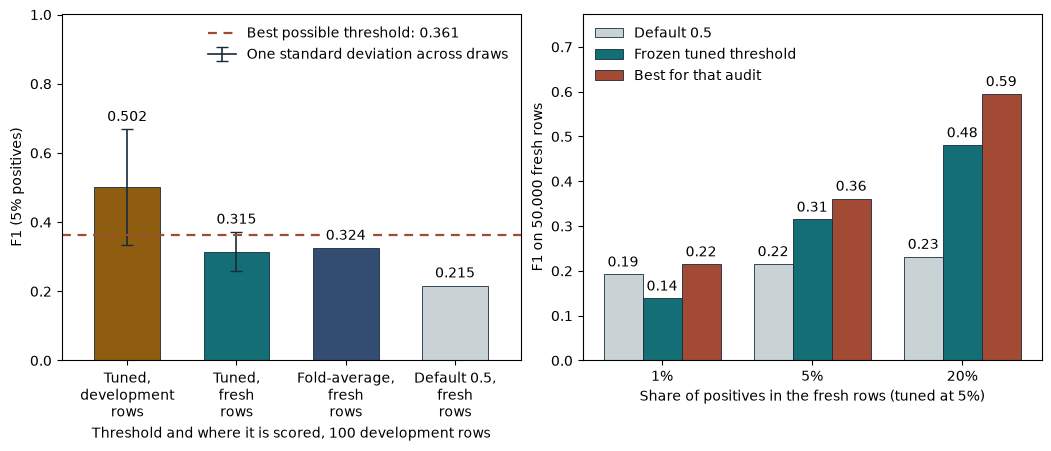

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch59 import draw, NCOLS, HEIGHT

DEFAULT = 100
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 100 development rows, the tuned threshold reaches an F1 of 0.502 on those rows but 0.315 on 50,000 fresh rows, so 0.502 - 0.315 = 0.187 is the optimism. The default 0.5 scores 0.215 on the fresh rows, so tuning gains 0.315 - 0.215 = 0.100 and beats the default in 93% of 300 draws. The best possible threshold scores 0.361. The tuned threshold itself varies by 0.132 (one standard deviation) around 0.225. Frozen at 5% positives and scored where only 1% are positive it gives 0.139 (default 0.5: 0.192), and at 20% positive 0.481 (best cut for that audit: 0.595).

- Optimism: 0.502 - 0.315 = +0.187 (development minus fresh rows).
- Gain over the default 0.5: 0.315 - 0.215 = +0.100.
- Shortfall against the best possible threshold: 0.361 - 0.315 = +0.046.
- Fold-averaged threshold minus single tuned threshold on fresh rows: 0.324 - 0.315 = +0.009.

## Apply this to your competition

- Tune the threshold on development predictions only, freeze it, and report its score on labels the search never saw.
- Expect the development score to overstate the frozen score, most of all when the development set holds few positives, and count positives, not rows.
- Compare the tuned threshold with the default and with a simple aggregate such as the average of fold thresholds before keeping a complicated recipe.
- Check the frozen threshold at the prevalence you expect in the test data; a threshold carries the class balance it was tuned on.

Book location: Chapter 59, When Threshold Optimization Overfits.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)